# Breast Cancer Segmentation – Semi Supervised AI System 
## AI Project SS2026

This project develops a **semi-supervised AI system** for automatic tumor segmentation in breast MRI images.

**Problem:** Manual tumor segmentation is time-consuming and requires expert radiologists,  
leaving most medical data unlabeled and unusable for supervised learning.

**Goal:** A semi-supervised pipeline that:
- Learns tumor patterns from labeled MRI scans
- Automatically generates **pseudo-ROI masks** for unlabeled data
- Evaluates results using segmentation metrics & visual comparison

**Workflow:** Data acquisition → Preprocessing → EDA → Visualization → Model Training → Evaluation

**Data Repository**
The dataset **"Advanced-MRI-Breast-Lesions"** ([doi.org/10.7937/C7X1-YN57](https://doi.org/10.7937/C7X1-YN57)) 
is from the public database *The Cancer Imaging Archive*. Dataset: 620+ breast MRI cases, ~99 with annotated ROI tumor masks
Due to its size of ~600 GB, it is currently stored on an external SSD.

**Code Repository**
[github.com/MelisaAta/AI_Project](https://github.com/MelisaAta/AI_Project.git)


In [1]:
import os
os.environ["PATH"] = r"C:\Program Files\NVIDIA GPU Computing Toolkit\CUDA\v11.8\bin;" + os.environ["PATH"]

<h2 style="color:#2e7d32">Processing of the dataset</h2>

#### Main subfolder used from the patients folders: "Registered AX Sen Vibrant C - Series" (Best input sequence - registered post-contrast)

In [1]:
# =============================================================================
# Preprocess Dataset:
#
# What it does, per patient:
#   1. Selects the Registered AX Sen Vibrant series (raw Vibrant as fallback).
#   2. Loads + sorts slices by Z (ImagePositionPatient[2]).
#   3. Normalizes with a BODY-VOXEL window  -> fixes the washed-out registered
#      look (the constant dark-fill floor no longer drags percentile(1) down).
#   4. If the patient has a tumour ROI (DICOM-SEG), aligns each mask frame to
#      the nearest image slice by Z (tolerance Z_TOLERANCE) and saves it
#      alongside the image. Patients without a usable ROI get an all-zero mask
#      and has_roi = False.
#   5. Resizes to IMAGE_SIZE, stores images as float16 + masks as uint8.
#
# Output:
#   - chunk_XXXX.pkl   : BLOCK_SIZE patients per file (RAM-safe)
#   - manifest.csv     : one row per patient (chunk, has_roi, n_slices, status)
#
# Labeled vs unlabeled are kept in ONE stream, distinguished by a per-slice
# `has_roi` flag (better than separate folders such as labeled and unlabeld patients: lets you split train/val/test
# per patient across both groups without leakage). Filter on has_roi to get the supervised subset at train time.
#
# Resumable: re-running skips patients already in manifest.csv and continues the chunk numbering, so a crash/interrupt never forces a full redo.
# ==========================================================================================================================================================

import os
import gc
import csv
import time
import pickle
import numpy as np
import pydicom

try:
    import cv2
    def _resize(a, size, nearest=False):
        return cv2.resize(a, (size[1], size[0]),
                          interpolation=cv2.INTER_NEAREST if nearest else cv2.INTER_AREA)
except ImportError:                       # fallback if opencv isn't installed
    from scipy.ndimage import zoom
    def _resize(a, size, nearest=False):
        zy, zx = size[0] / a.shape[0], size[1] / a.shape[1]
        return zoom(a, (zy, zx), order=0 if nearest else 1)

# =============================================================================
# CONFIGURATION  — edit paths here
# =============================================================================
DICOM_FOLDER = r"D:\Advanced-MRI-Breast-Lesions\DICOM Images\manifest-1713182663002\Advanced-MRI-Breast-Lesions"
OUT_DIR      = r"D:\Advanced-MRI-Breast-Lesions\data\chunks_semisup"
MANIFEST     = os.path.join(OUT_DIR, "manifest.csv")

IMAGE_SIZE   = (256, 256)     # (H, W) — final slice size
Z_TOLERANCE  = 0.5            # mm — max image<->mask Z distance for a match
BLOCK_SIZE   = 8              # patients per chunk file (raise if you have RAM)
P_LOW, P_HIGH = 1.0, 99.0     # contrast window percentiles (body voxels)
EXCLUDE_AIR  = False          # True = also drop air for max contrast (rarely needed)

DROP_AIR     = True           # skip near-empty UNLABELED slices (saves disk)
AIR_FRACTION = 0.995          # slice is "air" if >99.5% of pixels < 0.02
# labeled slices are ALWAYS kept (empty masks on non-lesion slices are valid
# negatives for supervised training)

os.makedirs(OUT_DIR, exist_ok=True)


# =============================================================================
# SERIES SELECTION  (registered preferred, raw Vibrant as fallback)
# =============================================================================
def is_registered_ax_vibrant(name):
    n = name.upper()
    return ("REGISTERED" in n and "AX" in n and "VIBRAN" in n
            and "MULTIPHASE" not in n and "T2" not in n and "MASK" not in n)

def is_raw_ax_vibrant(name):
    n = name.upper()
    return ("AX" in n and "VIBRAN" in n and "REGISTERED" not in n
            and "MULTIPHASE" not in n and "TRAM" not in n and "MASK" not in n)

def _series_number(name):
    try:
        return float(name.split(".")[0])
    except ValueError:
        return float("inf")

def select_series_folder(patient_subfolder, mode="auto"):
    """mode = 'registered' | 'raw' | 'auto' (registered, else raw)."""
    dirs = [d for d in os.listdir(patient_subfolder)
            if os.path.isdir(os.path.join(patient_subfolder, d))]
    reg = sorted([d for d in dirs if is_registered_ax_vibrant(d)], key=_series_number)
    raw = sorted([d for d in dirs if is_raw_ax_vibrant(d)],        key=_series_number)
    if mode in ("registered", "auto") and reg:
        return os.path.join(patient_subfolder, reg[0]), reg[0], "registered"
    if mode in ("raw", "auto") and raw:
        return os.path.join(patient_subfolder, raw[0]), raw[0], "raw"
    return None, None, None


# =============================================================================
# ORIENTATION + NORMALIZATION  (must match the verification script exactly)
# =============================================================================
def orient(x):
    """180 deg rotation == np.fliplr(np.flipud(x)). Apply to BOTH image and mask."""
    return np.rot90(x, 2)

def normalize_volume(vol, p_low=1.0, p_high=99.0, exclude_air=False):
    """
    Global percentile windowing with bounds estimated from BODY voxels only.
    Registered series fill out-of-FOV regions with a constant below the air
    background; that floor drags percentile(1) far down and the image turns
    foggy. Dropping that floor (and optionally air) restores crisp contrast.
    """
    v = np.nan_to_num(vol.astype(np.float32), nan=0.0, posinf=0.0, neginf=0.0)
    vmin, vmax = float(v.min()), float(v.max())
    eps  = (vmax - vmin) * 1e-3
    body = v[v > vmin + eps]                       # drop constant dark-fill plateau
    if exclude_air and body.size:
        thr = 0.10 * np.percentile(body, 99.5)
        body2 = body[body > thr]
        if body2.size > 1000:
            body = body2
    if body.size < 100:
        body = v.ravel()
    lo, hi = np.percentile(body, p_low), np.percentile(body, p_high)
    if hi - lo < 1e-6:
        lo, hi = vmin, vmax
    return np.clip((v - lo) / (hi - lo + 1e-6), 0.0, 1.0)


# =============================================================================
# DICOM LOADING + ROI ALIGNMENT
# =============================================================================
def _read_slices(series_folder):
    """Return [(z, 2D float32 array), ...] sorted by Z."""
    recs = []
    for f in os.listdir(series_folder):
        if not f.lower().endswith(".dcm"):
            continue
        try:
            ds  = pydicom.dcmread(os.path.join(series_folder, f))
            arr = ds.pixel_array.astype(np.float32)
            if arr.ndim == 3:                     # packed multi-frame safety
                arr = arr[arr.shape[0] // 2]
            z = float(ds.ImagePositionPatient[2]) if hasattr(ds, "ImagePositionPatient") else 0.0
            recs.append((z, arr))
        except Exception:
            continue
    recs.sort(key=lambda r: r[0])
    return recs

def find_roi_file(patient_subfolder):
    rois = [d for d in os.listdir(patient_subfolder)
            if os.path.isdir(os.path.join(patient_subfolder, d))
            and "ROI" in d.upper() and "TRAM" not in d.upper()]
    for d in rois:
        folder = os.path.join(patient_subfolder, d)
        for f in sorted(os.listdir(folder)):
            if f.lower().endswith(".dcm"):
                return os.path.join(folder, f), d
    return None, None

def load_seg_aligned(roi_file, image_zs, image_hw, z_tol=0.5):
    """Build a mask volume aligned to the image slices by nearest Z."""
    ds_seg  = pydicom.dcmread(roi_file)
    seg_arr = ds_seg.pixel_array.astype(np.uint8)
    if seg_arr.ndim == 2:
        seg_arr = seg_arr[None, ...]
    try:
        seg_zs = [float(fg.PlanePositionSequence[0].ImagePositionPatient[2])
                  for fg in ds_seg.PerFrameFunctionalGroupsSequence]
    except Exception:
        try:
            sg = ds_seg.SharedFunctionalGroupsSequence[0]
            z0 = float(sg.PlanePositionSequence[0].ImagePositionPatient[2])
            seg_zs = [z0] * seg_arr.shape[0]
        except Exception as e:
            raise RuntimeError(f"Could not read per-frame Z from SEG: {e}")
    seg_zs = np.array(seg_zs, dtype=float)

    z_to_mask = {}                                # union frames sharing a Z (multi-lesion)
    for i, z in enumerate(seg_zs):
        key = round(float(z), 2)
        frame = seg_arr[i] > 0
        z_to_mask[key] = (z_to_mask[key] | frame) if key in z_to_mask else frame
    uniq_z = np.array(sorted(z_to_mask.keys()))

    H, W = int(image_hw[0]), int(image_hw[1])
    aligned, dists = np.zeros((len(image_zs), H, W), np.uint8), []
    for i, z in enumerate(image_zs):
        j = int(np.argmin(np.abs(uniq_z - z)))
        d = abs(uniq_z[j] - z)
        if d <= z_tol:
            m = z_to_mask[uniq_z[j]].astype(np.uint8)
            if m.shape != (H, W):
                m = (_resize(m, (H, W), nearest=True) > 0).astype(np.uint8)
            aligned[i] = (m > 0).astype(np.uint8)
            dists.append(d)

    n_matched = int((aligned.reshape(len(aligned), -1).sum(1) > 0).sum())
    return aligned, n_matched


# =============================================================================
# PER-PATIENT PROCESSING
# =============================================================================
def process_patient(pid):
    """Return dict(images, masks, has_roi, ...) or None if unusable."""
    p_path = os.path.join(DICOM_FOLDER, pid)
    subs = [d for d in os.listdir(p_path) if os.path.isdir(os.path.join(p_path, d))]
    if not subs:
        return None
    psub = os.path.join(p_path, subs[0])

    series_folder, sname, kind = select_series_folder(psub, mode="auto")
    if series_folder is None:
        return None

    recs = _read_slices(series_folder)
    if not recs:
        return None
    zs  = np.array([r[0] for r in recs])
    vol = np.stack([r[1] for r in recs], axis=0)
    vol = normalize_volume(vol, P_LOW, P_HIGH, EXCLUDE_AIR)   # SAME as verification

    # --- ROI (if present) ---
    roi_file, _ = find_roi_file(psub)
    has_roi = roi_file is not None
    n_matched = 0
    if has_roi:
        try:
            mask_vol, n_matched = load_seg_aligned(roi_file, zs, vol.shape[1:], Z_TOLERANCE)
            if n_matched == 0:               # ROI exists but nothing aligned -> unlabeled
                has_roi = False
        except Exception:
            has_roi = False
    if not has_roi:
        mask_vol = np.zeros_like(vol, dtype=np.uint8)

    # --- resize + filter + orient (image & mask identically) ---
    H, W = IMAGE_SIZE
    imgs, msks = [], []
    for i in range(vol.shape[0]):
        img, msk = vol[i], mask_vol[i]
        if DROP_AIR and msk.sum() == 0 and (img < 0.02).mean() > AIR_FRACTION:
            continue                          # drop background-only UNLABELED slices
        img_r = _resize(img, (H, W), nearest=False)
        msk_r = (_resize(msk, (H, W), nearest=True) if msk.max() > 0
                 else np.zeros((H, W), np.uint8))
        imgs.append(orient(img_r).astype(np.float16))
        msks.append((orient(msk_r) > 0).astype(np.uint8))
    if not imgs:
        return None

    return dict(
        pid=pid, sname=sname, kind=kind, has_roi=has_roi, n_matched=n_matched,
        images=np.stack(imgs)[..., None],         # (n, H, W, 1) float16
        masks=np.stack(msks)[..., None],          # (n, H, W, 1) uint8
    )


# =============================================================================
# MAIN LOOP  (resume + chunked flush + live progress)
# =============================================================================
def main():
    # ---- resume: which patients are already done? ----
    processed = set()
    if os.path.exists(MANIFEST):
        with open(MANIFEST, newline="") as f:
            processed = {row["patient_id"] for row in csv.DictReader(f)}
    else:
        with open(MANIFEST, "w", newline="") as f:
            csv.writer(f).writerow(
                ["patient_id", "chunk", "kind", "has_roi", "n_lesion_slices",
                 "n_slices", "status"])

    all_patients = sorted([d for d in os.listdir(DICOM_FOLDER)
                           if os.path.isdir(os.path.join(DICOM_FOLDER, d))])
    todo = [p for p in all_patients if p not in processed]
    chunk_idx = len([f for f in os.listdir(OUT_DIR)
                     if f.startswith("chunk_") and f.endswith(".pkl")])

    print("=" * 64)
    print(f"Total patients     : {len(all_patients)}")
    print(f"Already processed  : {len(processed)}")
    print(f"To process now     : {len(todo)}")
    print(f"Next chunk index   : {chunk_idx:04d}")
    print(f"Output folder      : {OUT_DIR}")
    print("=" * 64)

    buf = {"images": [], "masks": [], "pids": [], "hasroi": []}
    rows, n_block = [], 0
    tot_slices = tot_labeled = tot_lesion = n_ok = n_skip = n_roi = 0
    t0 = time.time()

    def flush(idx):
        if not buf["images"]:
            return idx
        chunk = {
            "images":      np.concatenate(buf["images"], 0),   # (N, H, W, 1) float16
            "masks":       np.concatenate(buf["masks"], 0),    # (N, H, W, 1) uint8
            "patient_ids": np.concatenate(buf["pids"], 0),     # (N,) per slice
            "has_roi":     np.concatenate(buf["hasroi"], 0),   # (N,) bool per slice
        }
        path = os.path.join(OUT_DIR, f"chunk_{idx:04d}.pkl")
        with open(path, "wb") as f:
            pickle.dump(chunk, f, protocol=4)
        with open(MANIFEST, "a", newline="") as f:
            csv.writer(f).writerows(rows)
        mb = chunk["images"].nbytes / 1e6 + chunk["masks"].nbytes / 1e6
        print(f"  -> wrote chunk_{idx:04d}.pkl  "
              f"slices={chunk['images'].shape[0]:>5}  "
              f"labeled={int(chunk['has_roi'].sum()):>5}  ({mb:.0f} MB)")
        for k in buf:
            buf[k].clear()
        rows.clear()
        del chunk
        gc.collect()
        return idx + 1

    for n, pid in enumerate(todo, 1):
        try:
            rec = process_patient(pid)
        except Exception as e:
            rec = None
            print(f"  [{n}/{len(todo)}] {pid}: ERROR {e}")

        if rec is None:
            n_skip += 1
            rows.append([pid, "-", "-", 0, 0, 0, "skipped"])
            continue

        k = rec["images"].shape[0]
        lesion = int(rec["masks"].reshape(k, -1).sum(1).astype(bool).sum())
        buf["images"].append(rec["images"])
        buf["masks"].append(rec["masks"])
        buf["pids"].append(np.array([pid] * k))
        buf["hasroi"].append(np.array([rec["has_roi"]] * k, dtype=bool))
        rows.append([pid, f"chunk_{chunk_idx:04d}.pkl", rec["kind"],
                     int(rec["has_roi"]), lesion, k, "ok"])

        n_ok += 1
        tot_slices += k
        if rec["has_roi"]:
            n_roi += 1
            tot_labeled += k
            tot_lesion += lesion
        n_block += 1

        # live progress every patient
        elapsed = time.time() - t0
        rate = n / elapsed if elapsed else 0
        eta = (len(todo) - n) / rate if rate else 0
        flag = "ROI" if rec["has_roi"] else " - "
        print(f"  [{n:>4}/{len(todo)}] {pid:<12} {flag}  "
              f"slices={k:>3} lesion={lesion:>3}  "
              f"({rate:.1f} pt/s, ETA {eta/60:.1f} min)", end="\r")

        if n_block >= BLOCK_SIZE:
            print()                              # newline before chunk message
            chunk_idx = flush(chunk_idx)
            n_block = 0

    print()
    chunk_idx = flush(chunk_idx)                 # final partial block

    print("=" * 64)
    print("DONE")
    print(f"  patients processed : {n_ok}   (skipped {n_skip})")
    print(f"  patients with ROI  : {n_roi}")
    print(f"  total slices saved : {tot_slices:,}")
    print(f"    labeled slices   : {tot_labeled:,}")
    print(f"    lesion slices    : {tot_lesion:,}  (mask actually non-empty)")
    print(f"    unlabeled slices : {tot_slices - tot_labeled:,}")
    print(f"  chunks written     : up to chunk_{chunk_idx-1:04d}.pkl")
    print(f"  manifest           : {MANIFEST}")
    print("=" * 64)


if __name__ == "__main__":
    main()

Total patients     : 632
Already processed  : 0
To process now     : 632
Next chunk index   : 0000
Output folder      : D:\Advanced-MRI-Breast-Lesions\data\chunks_semisup
  [   8/632] AMBL-008     ROI  slices=116 lesion= 23  (0.3 pt/s, ETA 41.5 min)
  -> wrote chunk_0000.pkl  slices=  924  labeled=  692  (182 MB)
  [  16/632] AMBL-016     ROI  slices=116 lesion= 11  (0.2 pt/s, ETA 46.4 min)
  -> wrote chunk_0001.pkl  slices=  928  labeled=  580  (182 MB)
  [  24/632] AMBL-024     ROI  slices=116 lesion= 13  (0.2 pt/s, ETA 50.5 min)
  -> wrote chunk_0002.pkl  slices=  928  labeled=  464  (182 MB)
  [  33/632] AMBL-033     ROI  slices=116 lesion=  5  (0.2 pt/s, ETA 50.7 min)
  -> wrote chunk_0003.pkl  slices=  928  labeled=  696  (182 MB)
  [  41/632] AMBL-041      -   slices=116 lesion=  0  (0.2 pt/s, ETA 53.8 min)
  -> wrote chunk_0004.pkl  slices=  928  labeled=  464  (182 MB)
  [  50/632] AMBL-050     ROI  slices=116 lesion=  5  (0.2 pt/s, ETA 54.9 min)
  -> wrote chunk_0005.pkl  sli

### Changing paths from local to Repository 

Chunk size was to big to load onto the Repo (~13GB), so before the split everything was done on the external SSD containing the MRI data.

In [9]:
import os, glob

# chunks on the SSD (already confirmed working)
CHUNK_DIR    = r"D:\Advanced-MRI-Breast-Lesions\data\chunks_semisup"
DICOM_FOLDER = r"D:\Advanced-MRI-Breast-Lesions\DICOM Images\manifest-1713182663002\Advanced-MRI-Breast-Lesions"

# auto-find the metadata files anywhere under the repo (working dir)
def _find(name):
    hits = glob.glob(os.path.join("**", name), recursive=True)
    return os.path.abspath(hits[0]) if hits else None

MANIFEST   = _find("manifest.csv")
SPLIT_FILE = _find("split.json")

print("working dir :", os.getcwd())
print("manifest    :", MANIFEST)
print("split.json  :", SPLIT_FILE)
print("chunks found:", len(glob.glob(os.path.join(CHUNK_DIR, "chunk_*.pkl"))))

working dir : c:\Users\atame\Documents\GitHub\AI_Project
manifest    : c:\Users\atame\Documents\GitHub\AI_Project\Processed_and_Split_data\manifest.csv
split.json  : c:\Users\atame\Documents\GitHub\AI_Project\Processed_and_Split_data\split.json
chunks found: 77


### Dataset distribution overview

Reads only `manifest.csv` (one row per patient) - **no chunk files are opened**, so this
runs instantly. It summarises the processed dataset and answers "what does the data look
like before training":

- how many patients were processed vs skipped
- how many have a tumour ROI (labeled) vs none (unlabeled)
- total / labeled / lesion / unlabeled slice counts
- four distribution plots: slices per patient, labeled vs unlabeled slices,
  lesion slices per ROI patient, and patients by label availability

These numbers should match the summary printed at the end of the preprocessing run.

patients (ok)        : 613   | skipped: 19
  with ROI mask      : 94
  without ROI        : 519
total slices         : 70,973
  labeled            : 10,882
  lesion (mask>0)    : 1,178  (10.8% of labeled)
  unlabeled          : 60,091
series kind          : {'registered': 613}


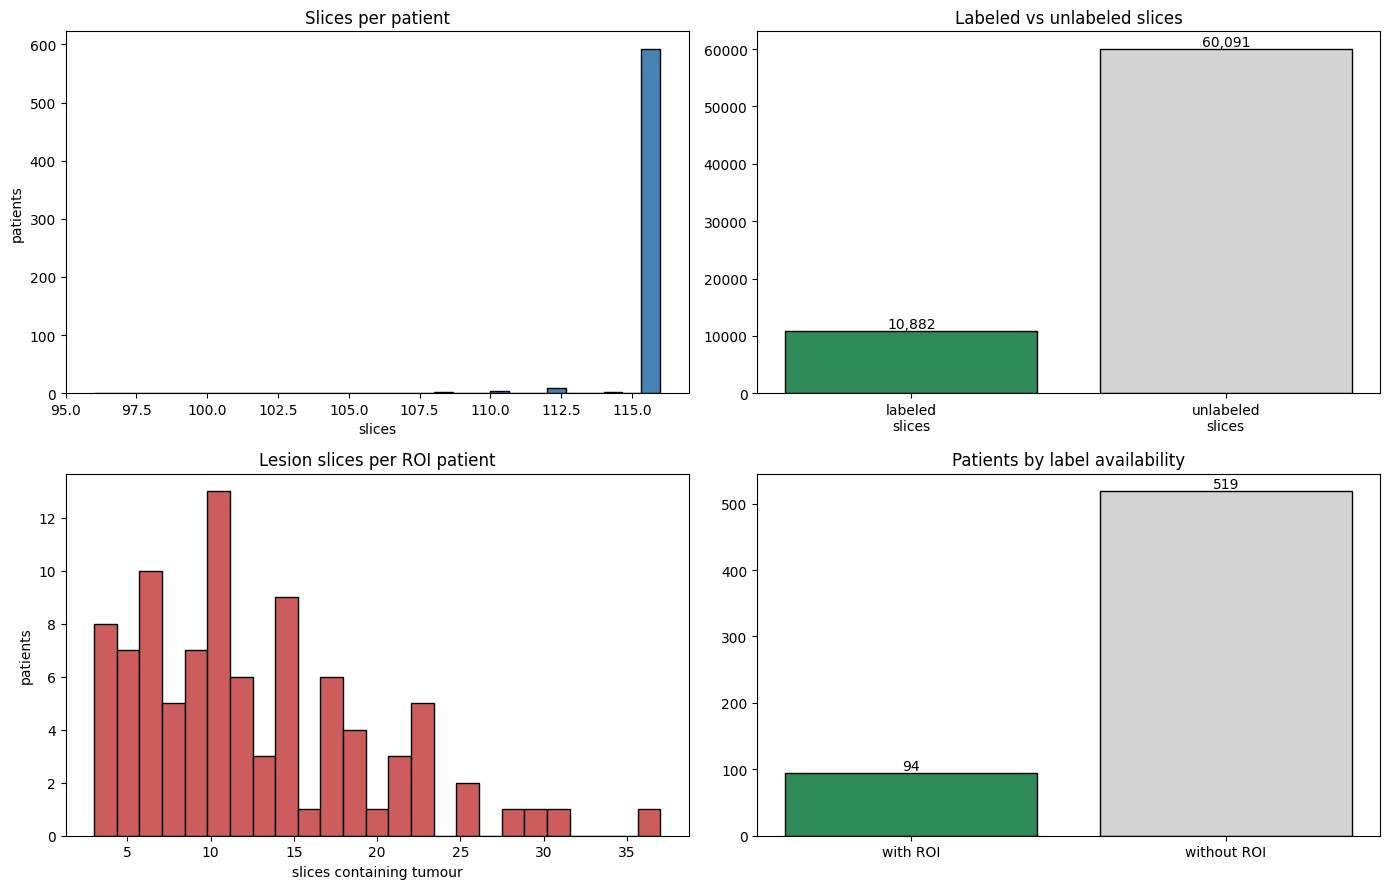

In [ ]:
import os, numpy as np, pandas as pd, matplotlib.pyplot as plt


# The manifest is the lightweight index written during preprocessing: one row per
# patient with chunk, kind, has_roi, n_lesion_slices, n_slices, status.
man = pd.read_csv(MANIFEST) 

# Keep only successfully processed patients; "skipped" rows (no series/unreadable) excluded.
ok  = man[man.status == "ok"].copy()
ok["has_roi"] = ok["has_roi"].astype(bool)   # CSV stored 0/1 -> convert to real booleans

# --- headline numbers, all derived by summing manifest columns (no pixel data needed) ---
n_pat      = len(ok)                                      # processed patients
n_roi      = int(ok.has_roi.sum())                        # patients with a usable ROI mask
tot_sl     = int(ok.n_slices.sum())                       # every saved slice
lab_sl     = int(ok.loc[ok.has_roi, "n_slices"].sum())   # slices belonging to ROI patients
lesion_sl  = int(ok.n_lesion_slices.sum())               # slices whose mask is non-empty
skipped    = man[man.status != "ok"].patient_id.tolist()

print(f"patients (ok)        : {n_pat}   | skipped: {len(skipped)}")
print(f"  with ROI mask      : {n_roi}")
print(f"  without ROI        : {n_pat - n_roi}")
print(f"total slices         : {tot_sl:,}")
print(f"  labeled            : {lab_sl:,}")
# lesion ratio shows how sparse tumour pixels are even within labeled data
print(f"  lesion (mask>0)    : {lesion_sl:,}  ({lesion_sl/lab_sl:.1%} of labeled)")
print(f"  unlabeled          : {tot_sl - lab_sl:,}")
print(f"series kind          : {dict(ok.kind.value_counts())}")   # registered vs raw fallback

fig, ax = plt.subplots(2, 2, figsize=(14, 9))

# (top-left) Spread of volume sizes — flags outlier patients with too few/many slices.
ax[0,0].hist(ok.n_slices, bins=30, color="steelblue", edgecolor="black")
ax[0,0].set_title("Slices per patient"); ax[0,0].set_xlabel("slices"); ax[0,0].set_ylabel("patients")

# (top-right) The core semi-supervised imbalance: how much data is labeled vs unlabeled.
ax[0,1].bar(["labeled\nslices", "unlabeled\nslices"], [lab_sl, tot_sl-lab_sl],
            color=["seagreen", "lightgray"], edgecolor="black")
ax[0,1].set_title("Labeled vs unlabeled slices")
for i, v in enumerate([lab_sl, tot_sl-lab_sl]):
    ax[0,1].text(i, v, f"{v:,}", ha="center", va="bottom")   # value label on each bar

# (bottom-left) Among ROI patients, how many tumour-bearing slices each contributes.
roi = ok[ok.has_roi]
ax[1,0].hist(roi.n_lesion_slices, bins=25, color="indianred", edgecolor="black")
ax[1,0].set_title("Lesion slices per ROI patient")
ax[1,0].set_xlabel("slices containing tumour"); ax[1,0].set_ylabel("patients")

# (bottom-right) Patient-level label availability (drives the supervised subset size).
ax[1,1].bar(["with ROI", "without ROI"], [n_roi, n_pat-n_roi],
            color=["seagreen", "lightgray"], edgecolor="black")
ax[1,1].set_title("Patients by label availability")
for i, v in enumerate([n_roi, n_pat-n_roi]):
    ax[1,1].text(i, v, str(v), ha="center", va="bottom")

plt.tight_layout(); plt.show()

### Integrity check (one streaming pass over all chunks)

The manifest tells us *what* was saved; this verifies the pixel data is actually *correct*.
Each chunk is loaded one at a time (RAM-safe), checked, then discarded. It confirms:

- **shapes** are (256, 256, 1) for images and masks
- **image values** lie in ~[0, 1] with no NaN/Inf (normalization didn't break)
- **masks are binary** (only 0 and 1)
- **no label leakage** - an unlabeled slice must never carry a mask
- **every ROI patient has ≥1 lesion slice** (otherwise the match silently failed)
- streamed totals **match the manifest** (no corruption / partial writes)

It also plots the tumour-mask size distribution (log scale) with the 100-pixel line -
the threshold below which masks are too small to train on reliably.

INTEGRITY REPORT
  slices streamed        : 70,973   (manifest: 70,973)
  image value range      : [0.000, 1.000]   (expect ~[0,1])
  non-finite pixels      : 0   (expect 0)
  non-binary mask chunks : 0   (expect 0)
  unlabeled-with-mask    : 0   (expect 0  -> no label leakage)
  ROI patients w/o lesion: 0   (expect 0)
  bad-shape chunks       : none
  lesion slices total    : 1,178   (manifest: 1,178)


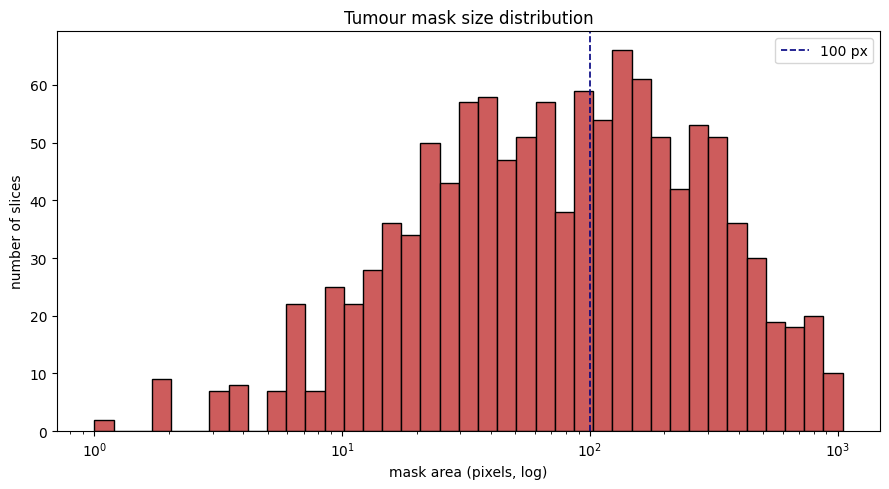

  masks < 100 px         : 657 / 1,178  (56%)


In [2]:
import glob, pickle
from collections import defaultdict

chunks = sorted(glob.glob(os.path.join(CHUNK_DIR, "chunk_*.pkl")))

# accumulators updated across all chunks
n_slices = 0; n_nonfinite = 0; mask_nonbinary = 0; leak = 0
img_min, img_max = np.inf, -np.inf
lesion_areas = []                      # pixel count of every non-empty mask
pat_lesion = defaultdict(int)          # patient -> number of lesion slices
pat_hasroi = {}                        # patient -> has_roi flag
shape_bad = []                         # chunks with wrong array shape

for cf in chunks:
    c = pickle.load(open(cf, "rb"))    # load ONE chunk (a few hundred MB max)
    im, mk = c["images"], c["masks"]
    pid, hr = c["patient_ids"], c["has_roi"]

    # 1) geometry: each slice must be a single-channel 256x256
    if im.shape[1:] != (256, 256, 1) or mk.shape[1:] != (256, 256, 1):
        shape_bad.append(os.path.basename(cf))

    # 2) image sanity: no NaN/Inf, and track the global value range
    if not np.isfinite(im).all():
        n_nonfinite += int((~np.isfinite(im)).sum())
    img_min = min(img_min, float(im.min())); img_max = max(img_max, float(im.max()))

    # 3) masks must be strictly binary (0/1)
    if mk.max() > 1 or mk.min() < 0:
        mask_nonbinary += 1

    # per-slice tumour pixel count (mask is 0/1, so the sum = area)
    areas = mk.reshape(len(mk), -1).sum(1)

    # 4) leakage guard: a slice flagged unlabeled (~hr) must have an empty mask
    leak += int(((~hr) & (areas > 0)).sum())

    lesion_areas.extend(areas[areas > 0].tolist())   # collect non-empty mask sizes
    n_slices += len(im)

    # aggregate lesion counts per patient (for the "ROI but no lesion" check)
    for p in np.unique(pid):
        s = pid == p
        pat_hasroi[p] = bool(hr[s][0])
        pat_lesion[p] += int((areas[s] > 0).sum())
    del c                                            # free the chunk before the next loop

# 5) any ROI patient that ended up with zero lesion slices = a failed/empty match
roi_no_lesion = [p for p, h in pat_hasroi.items() if h and pat_lesion[p] == 0]

print("INTEGRITY REPORT")
print(f"  slices streamed        : {n_slices:,}   (manifest: {int(ok.n_slices.sum()):,})")
print(f"  image value range      : [{img_min:.3f}, {img_max:.3f}]   (expect ~[0,1])")
print(f"  non-finite pixels      : {n_nonfinite}   (expect 0)")
print(f"  non-binary mask chunks : {mask_nonbinary}   (expect 0)")
print(f"  unlabeled-with-mask    : {leak}   (expect 0  -> no label leakage)")
print(f"  ROI patients w/o lesion: {len(roi_no_lesion)}   (expect 0)")
print(f"  bad-shape chunks       : {shape_bad or 'none'}")
print(f"  lesion slices total    : {len(lesion_areas):,}   (manifest: {int(ok.n_lesion_slices.sum()):,})")

# Mask-size distribution: log x-axis because sizes span orders of magnitude.
la = np.array(lesion_areas)
plt.figure(figsize=(9,5))
plt.hist(la, bins=np.logspace(0, np.log10(la.max()+1), 40), color="indianred", edgecolor="black")
plt.xscale("log"); plt.axvline(100, color="navy", ls="--", lw=1.2, label="100 px")
plt.xlabel("mask area (pixels, log)"); plt.ylabel("number of slices")
plt.title("Tumour mask size distribution"); plt.legend(); plt.tight_layout(); plt.show()
print(f"  masks < 100 px         : {(la < 100).sum():,} / {len(la):,}  ({(la<100).mean():.0%})")

### Visual QC - ROI overlay across random labeled patients

The numeric checks prove the data is *structurally* sound; this proves the masks are
*spatially* correct on patients other than the one we hand-verified. It samples random
ROI patients, finds each one's largest-tumour slice, and overlays the mask. If every
overlay sits on a plausible enhancing lesion, the Z-matching generalised across the
dataset. Re-run with a different seed to inspect more patients.

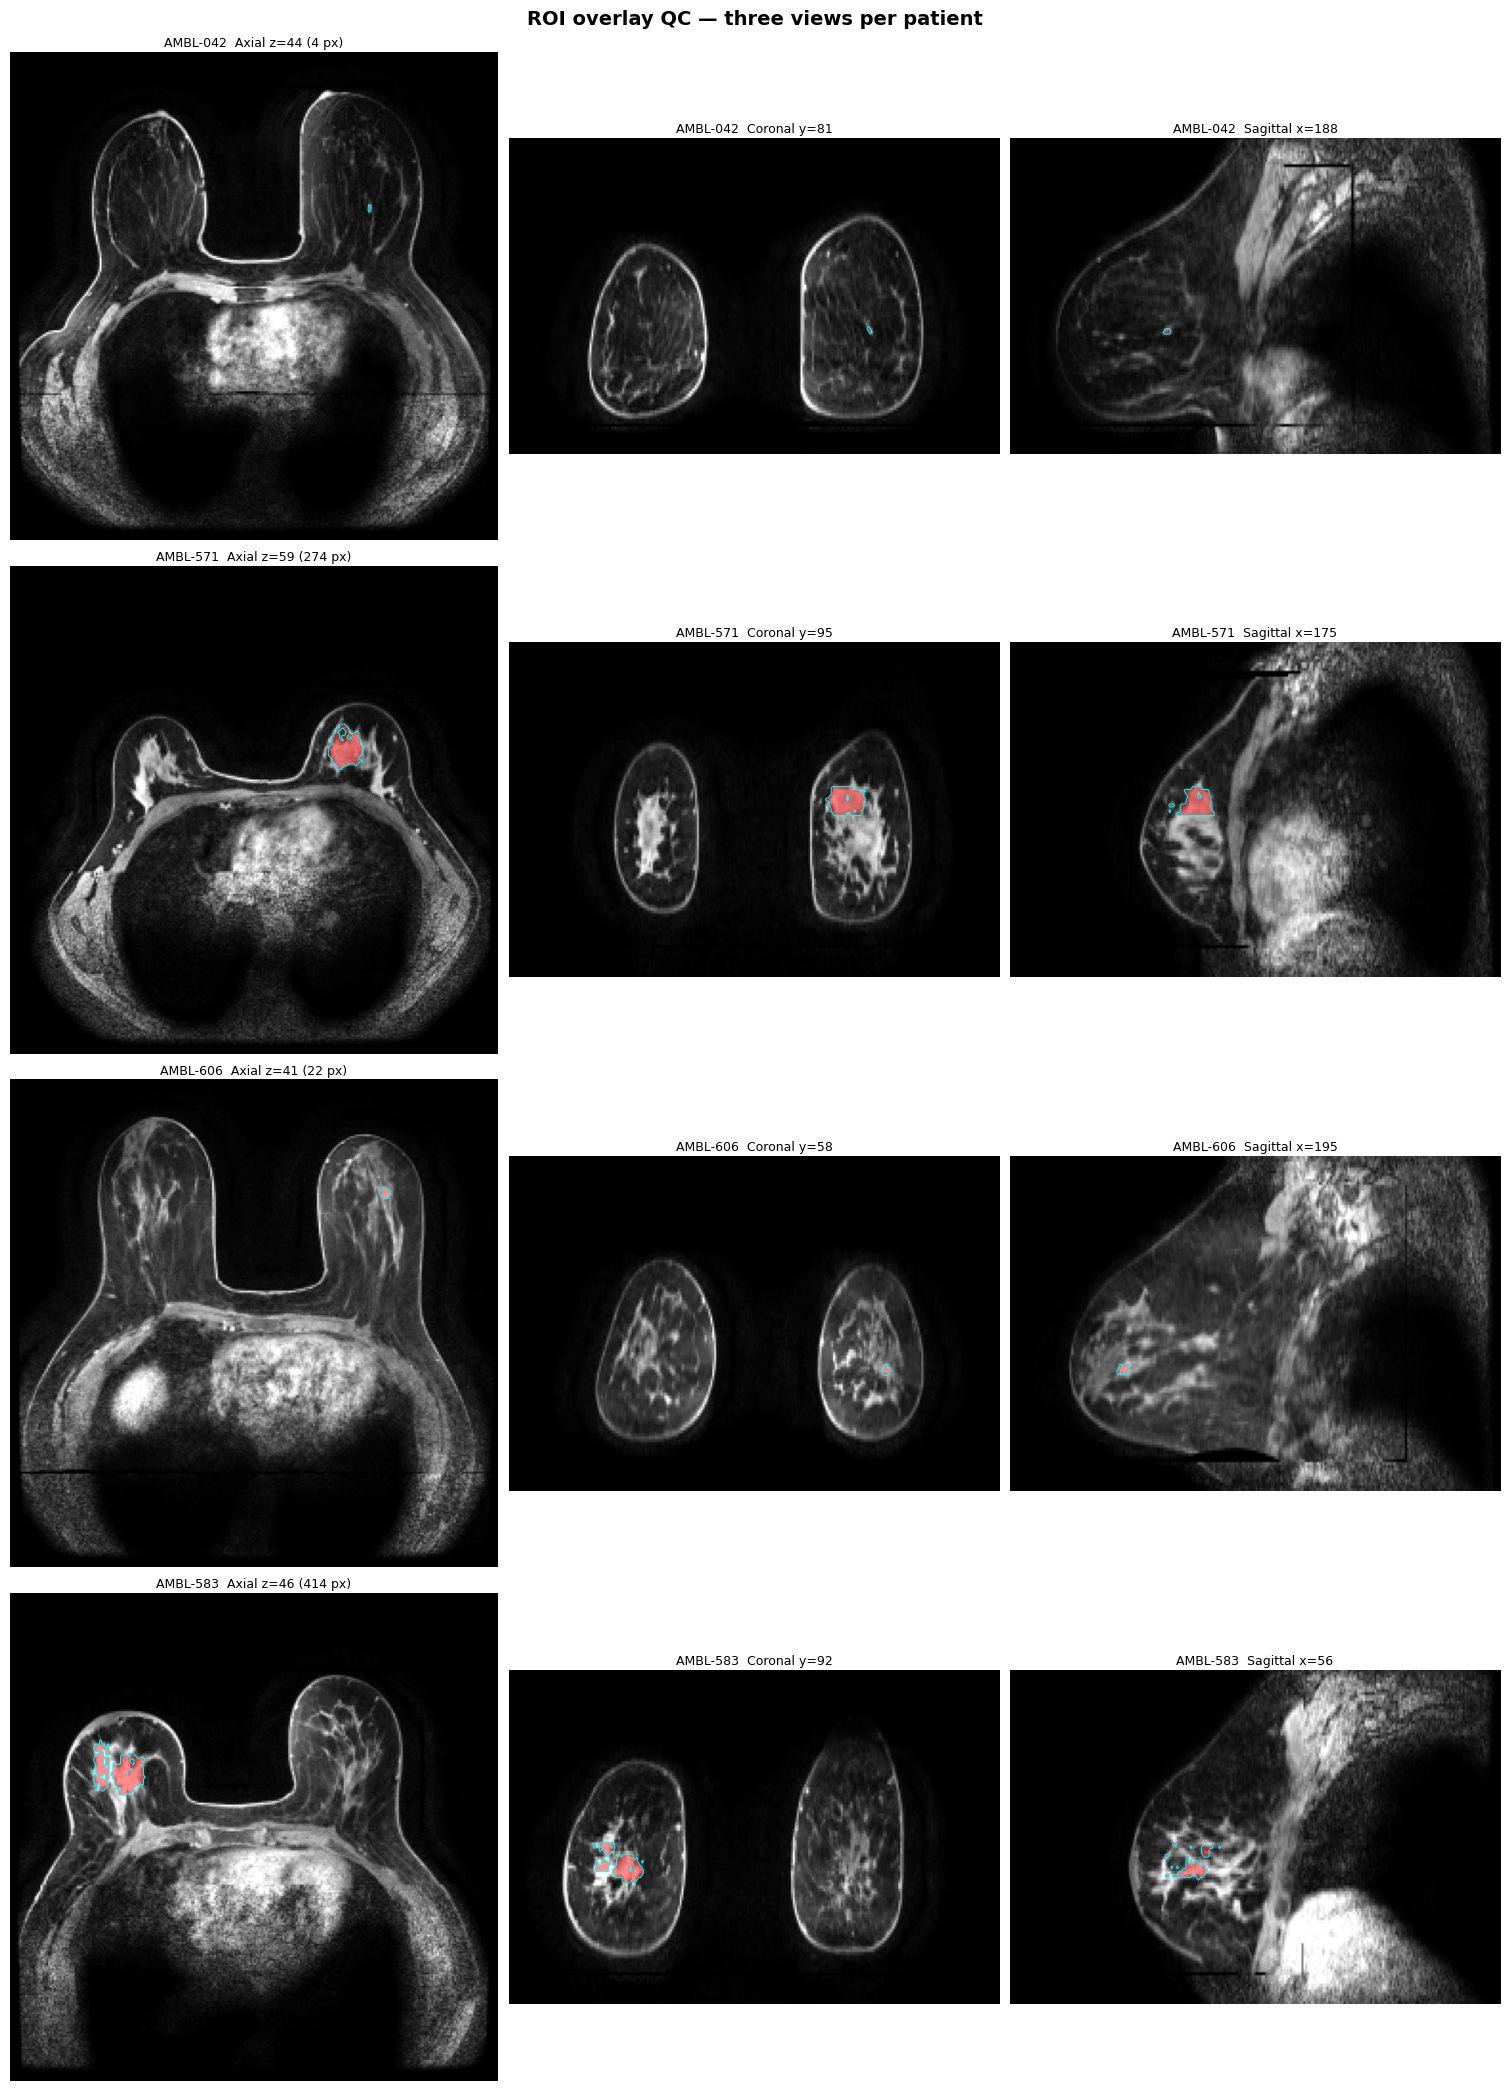

In [7]:
import os, glob, pickle, numpy as np, pandas as pd, pydicom, matplotlib.pyplot as plt

chunk_of     = dict(zip(ok.patient_id, ok.chunk))
N_PATIENTS   = 4
GRID         = 256   # stored slice size (H == W == 256)
DICOM_FOLDER = r"D:\Advanced-MRI-Breast-Lesions\DICOM Images\manifest-1713182663002\Advanced-MRI-Breast-Lesions"

def is_registered_ax_vibrant(name):
    n = name.upper()
    return ("REGISTERED" in n and "AX" in n and "VIBRAN" in n
            and "MULTIPHASE" not in n and "T2" not in n and "MASK" not in n)
def is_raw_ax_vibrant(name):
    n = name.upper()
    return ("AX" in n and "VIBRAN" in n and "REGISTERED" not in n
            and "MULTIPHASE" not in n and "TRAM" not in n and "MASK" not in n)
def _sn(name):
    try: return float(name.split(".")[0])
    except ValueError: return float("inf")

def get_grid_aspect(pid):
    """
    Aspect ratio of reformatted planes ON THE 256x256 GRID.
    After resizing an (orig x orig) slice to 256, in-plane spacing becomes
    in_plane * (orig/256). The z spacing is unchanged. The ratio we need for
    coronal/sagittal is (z spacing) / (resized in-plane spacing).
    """
    p_path = os.path.join(DICOM_FOLDER, pid)
    psub   = os.path.join(p_path, next(d for d in os.listdir(p_path)
                                       if os.path.isdir(os.path.join(p_path, d))))
    dirs = [d for d in os.listdir(psub) if os.path.isdir(os.path.join(psub, d))]
    reg  = sorted([d for d in dirs if is_registered_ax_vibrant(d)], key=_sn)
    raw  = sorted([d for d in dirs if is_raw_ax_vibrant(d)], key=_sn)
    folder = os.path.join(psub, (reg or raw)[0])
    files = sorted(f for f in os.listdir(folder) if f.lower().endswith(".dcm"))

    zs, in_plane, orig = [], 1.0, GRID
    for f in files:
        ds = pydicom.dcmread(os.path.join(folder, f), stop_before_pixels=True)
        if hasattr(ds, "ImagePositionPatient"):
            zs.append(float(ds.ImagePositionPatient[2]))
        if hasattr(ds, "PixelSpacing"):
            in_plane = float(ds.PixelSpacing[0])
        if hasattr(ds, "Rows"):
            orig = int(ds.Rows)
    z_sp = float(np.median(np.abs(np.diff(sorted(zs))))) if len(zs) > 1 else 1.0
    resized_in_plane = in_plane * (orig / GRID)        # spacing on the 256 grid
    return z_sp / (resized_in_plane + 1e-6)            # rows(Z) : cols(in-plane)

def load_patient(pid):
    c = pickle.load(open(os.path.join(CHUNK_DIR, chunk_of[pid]), "rb"))
    s = c["patient_ids"] == pid
    return c["images"][s, ..., 0].astype(np.float32), c["masks"][s, ..., 0]

def overlay(ax, img, msk, aspect, title):
    ax.imshow(img, cmap="gray", aspect=aspect)
    if msk is not None and msk.sum() > 0:
        ax.imshow(np.ma.masked_where(msk == 0, msk), cmap="autumn", alpha=0.45, aspect=aspect)
        ax.contour(msk, levels=[0.5], colors="cyan", linewidths=0.7)
    ax.set_title(title, fontsize=9, pad=4)
    ax.axis("off")

roi_pids = ok[ok.has_roi].patient_id.tolist()
sample   = np.random.default_rng(0).choice(roi_pids, size=min(N_PATIENTS, len(roi_pids)),
                                           replace=False)

# constrained_layout reserves room for titles so they never overlap the row above
fig, axes = plt.subplots(len(sample), 3, figsize=(15, 5.2 * len(sample)),
                         constrained_layout=True)
if len(sample) == 1:
    axes = axes[None, :]

for row, pid in enumerate(sample):
    img, msk = load_patient(pid)
    Z, H, W = img.shape
    a = get_grid_aspect(pid)                            # z : in-plane on the 256 grid

    areas = msk.reshape(Z, -1).sum(1)
    zc = int(np.argmax(areas))
    ys, xs = np.where(msk[zc] > 0)
    yc, xc = (int(ys.mean()), int(xs.mean())) if len(ys) else (H // 2, W // 2)

    overlay(axes[row, 0], img[zc, :, :], msk[zc, :, :],
            1.0,                                         # axial = square in-plane
            f"{pid}  Axial z={zc} ({int(areas[zc])} px)")
    overlay(axes[row, 1], np.flipud(img[:, yc, :]), np.flipud(msk[:, yc, :]),
            a, f"{pid}  Coronal y={yc}")
    overlay(axes[row, 2], np.flipud(img[:, :, xc]), np.flipud(msk[:, :, xc]),
            a, f"{pid}  Sagittal x={xc}")

fig.suptitle("ROI overlay QC — three views per patient",
             fontsize=14, fontweight="bold")
plt.show()

### Patient-level train / val / test split (semi-supervised)

Splitting happens **per patient** so no patient appears in two sets (prevents data leakage).
Because validation and test require ground truth to score segmentation, they are drawn
**only from labeled (ROI) patients**, split 70/15/15. Every **unlabeled** patient goes into
the training pool as the unsupervised stream.

The split is saved as **patient-ID lists** in `split.json` - not slice indices into a giant
array. The training loader resolves IDs to chunks on the fly, so the full dataset never
has to sit in RAM. Fixed seed keeps it reproducible.

In [ ]:
import json

rng       = np.random.default_rng(42)                 # fixed seed = reproducible split
labeled   = sorted(ok[ok.has_roi].patient_id.tolist())    # patients with masks
unlabeled = sorted(ok[~ok.has_roi].patient_id.tolist())   # patients without masks

# shuffle labeled patients, then carve 15% test / 15% val / 70% train
lab = labeled.copy(); rng.shuffle(lab)
n = len(lab); n_test = round(0.15*n); n_val = round(0.15*n)
test      = sorted(lab[:n_test])
val       = sorted(lab[n_test:n_test+n_val])
train_lab = sorted(lab[n_test+n_val:])

# unlabeled patients are NOT split — they all join training (can't be evaluated, no GT)
split = {"seed": 42,
         "train_labeled":   train_lab,
         "train_unlabeled": unlabeled,
         "val":   val,
         "test":  test}

# load and save Split File
json.dump(split, open(SPLIT_FILE, "w"), indent=2)     # was: open(os.path.join(CHUNK_DIR, "split.json"), "w")
print(f"\nsaved -> {SPLIT_FILE}")

# report patient + slice counts per split (slice counts looked up from the manifest)
sl = dict(zip(ok.patient_id, ok.n_slices))
def slices(ids): return sum(sl[p] for p in ids)
print(f"{'split':<16}{'patients':>9}{'slices':>10}")
for name, ids in [("train_labeled", train_lab), ("train_unlabeled", unlabeled),
                  ("val", val), ("test", test)]:
    print(f"{name:<16}{len(ids):>9}{slices(ids):>10,}")
print(f"\nsaved -> {os.path.join(CHUNK_DIR, 'split.json')}")
print("val/test are labeled-only (need ground truth to score). "
      "All unlabeled patients feed the train pool's unsupervised stream.")

split            patients    slices
train_labeled          66     7,634
train_unlabeled       519    60,091
val                    14     1,624
test                   14     1,624

saved -> D:\Advanced-MRI-Breast-Lesions\data\chunks_semisup\split.json
val/test are labeled-only (need ground truth to score). All unlabeled patients feed the train pool's unsupervised stream.


<h2 style="color:#e65100">Streaming Data Loader </h2>

Feeds image/mask batches to the model **without loading the whole dataset into RAM** —
it streams one chunk at a time. Reads chunks from the SSD and the split from the repo.

- **`DataIndex`** scans the chunks once and indexes every slice (which chunk, patient,
  labeled?, lesion?), so any slice can be pulled on demand.
- **Lesion oversampling** (`lesion_fraction`) fills each training batch with ~50% tumour
  slices, fixing the empty-mask imbalance. Use `None` for val/test.
- **Synchronized augmentation** applies the same flips/rotations to image and mask.
- Serves two modes: **supervised** `(image, mask)` for the baseline, and
  **semi-supervised** `((labeled img, mask), unlabeled img)` per step.

Output: `tf.data.Dataset` batches of shape `(B, 256, 256, 1)`, ready for `model.fit()`.

In [1]:
# =============================================================================
# Streaming data loader for the semi-supervised breast-MRI segmentation pipeline.
#
# Path scheme:
#   - chunk_XXXX.pkl  : large -> stay on the SSD (CHUNK_DIR)
#   - split.json      : small -> lives in the repo (SPLIT_FILE)
#
# Reads the chunk files produced by preprocess_dataset and the split.json
# produced during the verification/split step, and yields batches WITHOUT ever
# holding the whole dataset in RAM.
#
# Two modes from one code base:
#   - supervised        : labeled images + masks only (for the baseline)
#   - semi-supervised   : a labeled batch AND an unlabeled batch per step
#
# Two loader APIs are provided, both reading from the same DataIndex:
#   - tf.data generators  -> make_supervised_dataset / make_semisup_dataset
#   - tf.keras Sequence   -> StreamSeq (handy for model.fit(..., workers=N) or
#                            simpler step-by-step debugging)
#
# Key behaviours (where the class imbalance is actually handled):
#   - lesion oversampling : each labeled batch is filled to a target fraction
#                           of tumour-bearing slices
#   - synchronized aug    : the same random flip/rotation to image and mask
#   - chunk-cached        : one chunk held at a time; an index maps every
#                           (patient, slice) to its chunk
#
# Usage:
#   from data_loader import DataIndex, make_supervised_dataset, make_semisup_dataset
#   idx = DataIndex()                                   # uses CHUNK_DIR + SPLIT_FILE
#   train_ds = make_supervised_dataset(idx, "train_labeled", batch_size=16,
#                                      lesion_fraction=0.5, augment=True)
#   val_ds   = make_supervised_dataset(idx, "val", lesion_fraction=None, augment=False)
#
#   # or, with the Keras Sequence API instead of tf.data:
#   train_seq = StreamSeq(idx, "train_labeled", BATCH_SIZE,
#                         lesion_fraction=LESION_FRACTION, augment=True, seed=42)
#   val_seq   = StreamSeq(idx, "val", BATCH_SIZE, lesion_fraction=None, augment=False)
# =============================================================================

import os
import json
import glob
import pickle
import numpy as np

try:
    import tensorflow as tf
except ImportError:
    tf = None


# =============================================================================
# CONFIG
# -----------------------------------------------------------------------------
# CHUNK_DIR  : SSD folder holding chunk_XXXX.pkl (large, gitignored)
# SPLIT_FILE : repo copy of split.json (small, version-controlled)
#
# SPLIT_FILE is given relative to the repo root; if you run from elsewhere,
# set it to an absolute path or adjust the prefix.
#
# BATCH_SIZE / LESION_FRACTION are defaults for the StreamSeq demo below;
# override them when you build train_seq/val_seq in your training script.
# =============================================================================
CHUNK_DIR       = r"D:\Advanced-MRI-Breast-Lesions\data\chunks_semisup"
SPLIT_FILE      = os.path.join("data", "processed", "Processed_and_Split_data", "split.json")
IMAGE_SIZE      = (256, 256)
BATCH_SIZE      = 16
LESION_FRACTION = 0.5


# =============================================================================
# DATA INDEX
# -----------------------------------------------------------------------------
# Scans every chunk ONCE and records, for each slice: which chunk it's in, its
# row inside that chunk, its patient id, whether it has a label, and whether its
# mask is non-empty (a "lesion" slice). Lets the generators pick exactly the
# slices they want and pull them by loading only the relevant chunk.
# =============================================================================
class DataIndex:
    def __init__(self, chunk_dir=CHUNK_DIR, split_file=SPLIT_FILE):
        self.chunk_dir = chunk_dir
        self.chunks = sorted(glob.glob(os.path.join(chunk_dir, "chunk_*.pkl")))
        if not self.chunks:
            raise FileNotFoundError(f"No chunk_*.pkl in {chunk_dir}")

        # resolve split.json: try as given, then relative to cwd, then search
        if not os.path.exists(split_file):
            cand = os.path.join(os.getcwd(), split_file)
            if os.path.exists(cand):
                split_file = cand
            else:
                hits = glob.glob(os.path.join(os.getcwd(), "**",
                                              os.path.basename(split_file)),
                                 recursive=True)
                if hits:
                    split_file = hits[0]
        if not os.path.exists(split_file):
            raise FileNotFoundError(
                f"split.json not found (looked for '{split_file}' and searched "
                f"under {os.getcwd()}). Set SPLIT_FILE to an absolute path.")
        with open(split_file) as f:
            self.split = json.load(f)

        # per-slice records, parallel arrays for speed
        self._chunk_id = []     # int index into self.chunks
        self._row      = []     # row inside that chunk
        self._pid      = []     # patient id (str)
        self._has_roi  = []     # bool, slice belongs to a labeled patient
        self._lesion   = []     # bool, mask non-empty

        # 1-chunk cache (access is mostly sequential within a chunk)
        self._cache_id = None
        self._cache    = None

        for ci, cf in enumerate(self.chunks):
            c = pickle.load(open(cf, "rb"))
            pids = c["patient_ids"]
            hr   = c["has_roi"]
            areas = c["masks"].reshape(len(c["masks"]), -1).sum(1)
            n = len(pids)
            self._chunk_id.extend([ci] * n)
            self._row.extend(range(n))
            self._pid.extend(pids.tolist())
            self._has_roi.extend(hr.tolist())
            self._lesion.extend((areas > 0).tolist())
            del c

        self._chunk_id = np.array(self._chunk_id)
        self._row      = np.array(self._row)
        self._pid      = np.array(self._pid)
        self._has_roi  = np.array(self._has_roi, dtype=bool)
        self._lesion   = np.array(self._lesion, dtype=bool)

    def _get_chunk(self, ci):
        if ci != self._cache_id:
            self._cache    = pickle.load(open(self.chunks[ci], "rb"))
            self._cache_id = ci
        return self._cache

    def get_slice(self, global_i):
        """Return (image (H,W,1) float32, mask (H,W,1) float32) for one slice."""
        c = self._get_chunk(self._chunk_id[global_i])
        r = self._row[global_i]
        img = c["images"][r].astype(np.float32)        # float16 -> float32
        msk = c["masks"][r].astype(np.float32)         # 0/1 uint8 -> float32
        return img, msk

    def indices_for(self, split_name, lesion_only=False):
        pid_set = set(self.split[split_name])
        sel = np.array([p in pid_set for p in self._pid])
        if lesion_only:
            sel &= self._lesion
        return np.where(sel)[0]


# =============================================================================
# SYNCHRONIZED AUGMENTATION  (numpy - same transform to image and mask)
#
# Used by both the tf.data generators below and StreamSeq, so there's a single
# source of truth for the flip/rotation logic.
# =============================================================================
def _augment_pair(img, msk, rng):
    if rng.random() < 0.5:
        img = img[:, ::-1]; msk = msk[:, ::-1]
    if rng.random() < 0.5:
        img = img[::-1, :]; msk = msk[::-1, :]
    k = rng.integers(0, 4)
    if k:
        img = np.rot90(img, k); msk = np.rot90(msk, k)
    return np.ascontiguousarray(img), np.ascontiguousarray(msk)


# =============================================================================
# PYTHON GENERATORS
# =============================================================================
def _labeled_generator(index, split_name, batch_size, lesion_fraction,
                       augment, seed, infinite):
    """
    lesion_fraction:
      None  -> natural order (val/test; no resampling)
      0..1  -> each batch ~this fraction lesion slices (training imbalance fix)
    """
    rng = np.random.default_rng(seed)
    all_idx    = index.indices_for(split_name, lesion_only=False)
    lesion_idx = index.indices_for(split_name, lesion_only=True)
    empty_idx  = np.setdiff1d(all_idx, lesion_idx)

    if lesion_fraction is None:
        order = all_idx
        while True:
            for s in range(0, len(order), batch_size):
                batch = order[s:s + batch_size]
                imgs, msks = zip(*(index.get_slice(i) for i in batch))
                yield np.stack(imgs), np.stack(msks)
            if not infinite:
                return
    else:
        n_lesion = max(1, int(round(batch_size * lesion_fraction)))
        n_empty  = batch_size - n_lesion
        while True:
            pick_l = rng.choice(lesion_idx, n_lesion, replace=len(lesion_idx) < n_lesion)
            pick_e = (rng.choice(empty_idx, n_empty, replace=len(empty_idx) < n_empty)
                      if n_empty and len(empty_idx) else np.array([], dtype=int))
            batch = np.concatenate([pick_l, pick_e]); rng.shuffle(batch)
            pairs = [index.get_slice(i) for i in batch]
            if augment:
                pairs = [_augment_pair(im, mk, rng) for im, mk in pairs]
            imgs, msks = zip(*pairs)
            yield np.stack(imgs), np.stack(msks)
            if not infinite:
                return


def _unlabeled_generator(index, batch_size, augment, seed, infinite):
    rng = np.random.default_rng(seed)
    idx = index.indices_for("train_unlabeled", lesion_only=False)
    while True:
        rng.shuffle(idx)
        for s in range(0, len(idx), batch_size):
            batch = idx[s:s + batch_size]
            imgs = [index.get_slice(i)[0] for i in batch]
            if augment:
                imgs = [_augment_pair(im, im, rng)[0] for im in imgs]
            yield np.stack(imgs)
        if not infinite:
            return


# =============================================================================
# KERAS SEQUENCE STREAMING LOADER (alternative to the tf.data generators below)
# -----------------------------------------------------------------------------
# Same streaming/oversampling behaviour as _labeled_generator, just packaged
# as a tf.keras.utils.Sequence so it can be passed straight to model.fit(),
# including with workers>1 / use_multiprocessing=True if you want that.
#
# - lesion_fraction=None  -> validation/test: fixed sequential batches
# - lesion_fraction=0..1  -> training: each batch resampled to ~this fraction
#                            of lesion slices, length = total slices // bs
# =============================================================================
_SequenceBase = tf.keras.utils.Sequence if tf is not None else object


class StreamSeq(_SequenceBase):
    """
    Reads slices straight from the chunks per batch instead of loading
    everything into RAM, because the machine is already near its memory
    limit. For training, oversamples tumour slices (lesion_fraction); for
    validation, just goes through the slices in order.
    """
    def __init__(self, index, split_name, batch_size,
                 lesion_fraction=None, augment=False, seed=0):
        if tf is None:
            raise ImportError("TensorFlow is required for StreamSeq")
        self.index = index
        self.bs = batch_size
        self.lf = lesion_fraction
        self.aug = augment
        self.rng = np.random.default_rng(seed)

        # grab the global slice indices for this split once (cheap, just ints)
        self.all = index.indices_for(split_name, lesion_only=False)
        self.les = index.indices_for(split_name, lesion_only=True)
        self.emp = np.setdiff1d(self.all, self.les)

        if lesion_fraction is None:
            # validation: fixed number of sequential batches
            self.order = self.all
            self.steps = int(np.ceil(len(self.all) / batch_size))
        else:
            # training: resample every epoch, so length is based on total slices
            self.steps = max(1, len(self.all) // batch_size)

    def __len__(self):
        return self.steps

    def __getitem__(self, i):
        if self.lf is None:
            # validation: take the next sequential block of indices
            batch = self.order[i * self.bs:(i + 1) * self.bs]
        else:
            # training: fill the batch to ~lesion_fraction tumour slices
            n_lesion = max(1, int(round(self.bs * self.lf)))
            n_empty  = self.bs - n_lesion
            pick_l = self.rng.choice(self.les, n_lesion, replace=len(self.les) < n_lesion)
            pick_e = (self.rng.choice(self.emp, n_empty, replace=len(self.emp) < n_empty)
                      if n_empty and len(self.emp) else np.array([], dtype=int))
            batch = np.concatenate([pick_l, pick_e])
            self.rng.shuffle(batch)

        # pull each slice from its chunk and build the batch arrays
        H, W = IMAGE_SIZE
        bx = np.empty((len(batch), H, W, 1), np.float32)
        by = np.empty((len(batch), H, W, 1), np.float32)
        for k, gi in enumerate(batch):
            im, mk = self.index.get_slice(gi)
            if self.aug:
                im, mk = _augment_pair(im, mk, self.rng)
            bx[k] = im
            by[k] = mk
        return bx, by


# =============================================================================
# TF.DATA WRAPPERS
# =============================================================================
def make_supervised_dataset(index, split_name, batch_size=16,
                            lesion_fraction=0.5, augment=True, seed=42):
    if tf is None:
        raise ImportError("TensorFlow is required for make_supervised_dataset")
    H, W = IMAGE_SIZE
    infinite = lesion_fraction is not None

    def gen():
        yield from _labeled_generator(index, split_name, batch_size,
                                      lesion_fraction, augment, seed, infinite)

    sig = (tf.TensorSpec((None, H, W, 1), tf.float32),
           tf.TensorSpec((None, H, W, 1), tf.float32))
    return tf.data.Dataset.from_generator(gen, output_signature=sig).prefetch(tf.data.AUTOTUNE)


def make_semisup_dataset(index, labeled_split="train_labeled", batch_size=8,
                         lesion_fraction=0.5, augment=True, seed=42):
    if tf is None:
        raise ImportError("TensorFlow is required for make_semisup_dataset")
    H, W = IMAGE_SIZE

    def gen():
        lab = _labeled_generator(index, labeled_split, batch_size,
                                 lesion_fraction, augment, seed, infinite=True)
        unl = _unlabeled_generator(index, batch_size, augment, seed + 1, infinite=True)
        for (li, lm), ui in zip(lab, unl):
            yield (li, lm), ui

    sig = ((tf.TensorSpec((None, H, W, 1), tf.float32),
            tf.TensorSpec((None, H, W, 1), tf.float32)),
           tf.TensorSpec((None, H, W, 1), tf.float32))
    return tf.data.Dataset.from_generator(gen, output_signature=sig).prefetch(tf.data.AUTOTUNE)


def steps_per_epoch(index, split_name, batch_size):
    return max(1, len(index.indices_for(split_name)) // batch_size)


# =============================================================================
# SELF-TEST
# =============================================================================
if __name__ == "__main__":
    idx = DataIndex()
    for name in ["train_labeled", "train_unlabeled", "val", "test"]:
        ii = idx.indices_for(name)
        les = idx.indices_for(name, lesion_only=True) if name != "train_unlabeled" else []
        print(f"{name:<16} slices={len(ii):>6}   lesion slices={len(les):>6}")

    print("\nlabeled batch check (lesion_fraction=0.5):")
    g = _labeled_generator(idx, "train_labeled", 16, 0.5, True, 0, infinite=False)
    imgs, msks = next(g)
    frac = np.mean([m.sum() > 0 for m in msks])
    print(f"  images {imgs.shape} {imgs.dtype}  range[{imgs.min():.2f},{imgs.max():.2f}]")
    print(f"  masks  {msks.shape}  unique={np.unique(msks)}")
    print(f"  lesion fraction in batch = {frac:.2f}  (target ~0.5)")

    print("\nunlabeled batch check:")
    gu = _unlabeled_generator(idx, 8, False, 0, infinite=False)
    u = next(gu)
    print(f"  images {u.shape} {u.dtype}  range[{u.min():.2f},{u.max():.2f}]")

    print("\nStreamSeq (Keras Sequence) demo:")
    train_seq = StreamSeq(idx, "train_labeled", BATCH_SIZE,
                          lesion_fraction=LESION_FRACTION, augment=True, seed=42)
    val_seq   = StreamSeq(idx, "val", BATCH_SIZE, lesion_fraction=None, augment=False)
    print("  train steps:", len(train_seq), "| val steps:", len(val_seq))
    bx, by = train_seq[0]
    frac_seq = np.mean([m.sum() > 0 for m in by])
    print(f"  train batch: x{bx.shape} y{by.shape}  lesion fraction={frac_seq:.2f}")

train_labeled    slices=  7634   lesion slices=   878
train_unlabeled  slices= 60091   lesion slices=     0
val              slices=  1624   lesion slices=   149
test             slices=  1624   lesion slices=   151

labeled batch check (lesion_fraction=0.5):
  images (16, 256, 256, 1) float32  range[0.00,1.00]
  masks  (16, 256, 256, 1)  unique=[0. 1.]
  lesion fraction in batch = 0.50  (target ~0.5)

unlabeled batch check:
  images (8, 256, 256, 1) float32  range[0.00,1.00]

StreamSeq (Keras Sequence) demo:
  train steps: 477 | val steps: 102
  train batch: x(16, 256, 256, 1) y(16, 256, 256, 1)  lesion fraction=0.50


<h2 style="color:#1565c0">Supervised Baseline - Attention U-Net</h2>
Trains the segmentation model on the "labeled patients only" - the baseline we'll later
compare the semi-supervised version against.

- **Model:** Attention U-Net, trained from scratch, single-channel input. The attention
  gates help it focus on small tumours and ignore background.
- **Loss:** Focal Tversky (α=0.9, β=0.1, γ=1.0) - heavily penalizes missed tumour pixels
  to counter the background/foreground imbalance.
- **Metrics:** Dice and IoU, so we track real segmentation quality, not pixel accuracy.
- **Data:** streamed from `data_loader` with ~50% lesion slices per batch.
- **Callbacks:** saves the best model (by val Dice), stops early on plateau, and lowers
  the learning rate when validation stalls - all written to `results/models/`.


In [2]:
import os, numpy as np, tensorflow as tf
from tensorflow.keras import layers, Model
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping, ReduceLROnPlateau, CSVLogger

# let GPU memory grow on demand instead of grabbing all 6 GB at startup 
for gpu in tf.config.list_physical_devices("GPU"):
    try: tf.config.experimental.set_memory_growth(gpu, True)
    except Exception: pass

# mixed precision: compute in float16 -> ~half the GPU memory, often faster 
tf.keras.mixed_precision.set_global_policy("mixed_float16")

# training config (tuned for a 6 GB GPU) 
BATCH_SIZE      = 4       # small batch because of 6 GB VRAM; try 8 later if stable
EPOCHS          = 60      # upper bound; EarlyStopping usually stops sooner
LR              = 1e-4    # learning rate (thesis value)
LESION_FRACTION = 0.5     # ~50% tumour slices per training batch (fights imbalance)
BASE_FILTERS    = 16      # model width halved (32->16) -> ~4x less memory

# Focal Tversky params 
# high alpha = missed tumour pixels punished hard
# for a stronger focus on small/hard lesions if recall is too low.
ALPHA, BETA, GAMMA = 0.9, 0.1, 1.0

# save the best model and the training history 
MODEL_DIR = os.path.join("results", "models"); os.makedirs(MODEL_DIR, exist_ok=True)
BEST_PATH = os.path.join(MODEL_DIR, "attn_unet_supervised.keras")
HIST_PATH = os.path.join(MODEL_DIR, "history_supervised.csv")

INFO:tensorflow:Mixed precision compatibility check (mixed_float16): OK
Your GPU will likely run quickly with dtype policy mixed_float16 as it has compute capability of at least 7.0. Your GPU: NVIDIA GeForce RTX 3060 Laptop GPU, compute capability 8.6


### Model - Attention U-Net
Builds the segmentation network: an encoder–decoder with attention gates on the
skip connections so the model focuses on tumour regions. Trained from scratch,
single-channel input, per-pixel sigmoid output.

In [3]:
def conv_block(x, f):
    """Two conv layers with BatchNorm + ReLU (standard U-Net block)."""
    x = layers.Conv2D(f, 3, padding="same")(x); x = layers.BatchNormalization()(x); x = layers.Activation("relu")(x)
    x = layers.Conv2D(f, 3, padding="same")(x); x = layers.BatchNormalization()(x); x = layers.Activation("relu")(x)
    return x

def attention_gate(skip, gate, inter):
    """
    Additive attention gate (Oktay et al.). Weights the skip connection so the
    model emphasizes relevant regions (tumour) and suppresses background.
    'skip' and 'gate' share the same spatial size.
    """
    tx  = layers.Conv2D(inter, 1)(skip)
    pg  = layers.Conv2D(inter, 1)(gate)
    act = layers.Activation("relu")(layers.Add()([tx, pg]))
    psi = layers.Activation("sigmoid")(layers.Conv2D(1, 1)(act))   # attention map in [0,1]
    return layers.Multiply()([skip, psi])                          # gate the skip features

def build_attention_unet(input_shape=(256, 256, 1), base=16):
    inp = layers.Input(input_shape)

    # encoder: extract features, downsample spatially 
    c1 = conv_block(inp, base);    p1 = layers.MaxPooling2D()(c1)
    c2 = conv_block(p1, base*2);   p2 = layers.MaxPooling2D()(c2)
    c3 = conv_block(p2, base*4);   p3 = layers.MaxPooling2D()(c3)
    c4 = conv_block(p3, base*8);   p4 = layers.MaxPooling2D()(c4)

    # bottleneck: deepest, most abstract level 
    bn = conv_block(p4, base*16)

    # decoder: upsample -> attention-gate the skip -> concat -> conv 
    u4 = layers.Conv2DTranspose(base*8, 2, strides=2, padding="same")(bn)
    c5 = conv_block(layers.concatenate([u4, attention_gate(c4, u4, base*8)]), base*8)
    u3 = layers.Conv2DTranspose(base*4, 2, strides=2, padding="same")(c5)
    c6 = conv_block(layers.concatenate([u3, attention_gate(c3, u3, base*4)]), base*4)
    u2 = layers.Conv2DTranspose(base*2, 2, strides=2, padding="same")(c6)
    c7 = conv_block(layers.concatenate([u2, attention_gate(c2, u2, base*2)]), base*2)
    u1 = layers.Conv2DTranspose(base, 2, strides=2, padding="same")(c7)
    c8 = conv_block(layers.concatenate([u1, attention_gate(c1, u1, base)]), base)

    # output: 1x1 conv -> per-pixel tumour probability 
    # dtype="float32" forces the final layer back to full precision (required
    # under mixed precision so the sigmoid stays stable).
    out = layers.Conv2D(1, 1, activation="sigmoid", dtype="float32")(c8)
    return Model(inp, out, name="attention_unet")

### Loss & Metrics
Focal Tversky loss to handle the background/foreground imbalance, plus Dice and
IoU as metrics to measure real segmentation quality during training.

In [4]:
def dice_coef(y_true, y_pred, smooth=1e-6):
    """Dice overlap (soft): 2*intersection / (sum of both). Higher = better."""
    yt = tf.reshape(y_true, [-1]); yp = tf.reshape(y_pred, [-1])
    inter = tf.reduce_sum(yt * yp)
    return (2*inter + smooth) / (tf.reduce_sum(yt) + tf.reduce_sum(yp) + smooth)

def iou_metric(y_true, y_pred, smooth=1e-6):
    """Intersection-over-Union on the thresholded prediction (>0.5)."""
    yt = tf.reshape(y_true, [-1]); yp = tf.reshape(tf.cast(y_pred > 0.5, tf.float32), [-1])
    inter = tf.reduce_sum(yt * yp); union = tf.reduce_sum(yt) + tf.reduce_sum(yp) - inter
    return (inter + smooth) / (union + smooth)

def focal_tversky_loss(alpha=ALPHA, beta=BETA, gamma=GAMMA, smooth=1e-6):
    """
    Tversky index weights false negatives (alpha) vs false positives (beta);
    the focal exponent (gamma) emphasizes hard cases. Designed for heavy
    foreground/background imbalance like tiny tumour masks.
    """
    def loss(y_true, y_pred):
        yt = tf.reshape(y_true, [-1]); yp = tf.reshape(y_pred, [-1])
        tp = tf.reduce_sum(yt * yp)
        fn = tf.reduce_sum(yt * (1 - yp))
        fp = tf.reduce_sum((1 - yt) * yp)
        ti = (tp + smooth) / (tp + alpha*fn + beta*fp + smooth)   # Tversky index
        return tf.pow(1 - ti, gamma)                              # focal term
    return loss

### Training
Compiles the model and trains it, with callbacks that save the best model by
validation Dice, reduce the learning rate on plateau, and stop early when it
stops improving.

In [8]:
# =============================================================================
# SUPERVISED BASELINE TRAINING  — Attention U-Net
#
# Replaces the old load_split_to_ram + BalancedSeq/ArraySeq approach.
# Data is streamed chunk-by-chunk via DataIndex so the full dataset never
# sits in RAM. make_supervised_dataset handles lesion oversampling and
# synchronized augmentation internally.
# =============================================================================

# --- build the slice index (scans chunk headers once, no pixel data loaded) ---
idx = DataIndex()

# --- training dataset ---
# lesion_fraction=0.5 : each batch is ~50% tumour-bearing slices
#                       (fixes the heavy background/foreground imbalance)
# augment=True        : synchronized random flips + rotations on image & mask
train_ds = make_supervised_dataset(
    idx, "train_labeled",
    batch_size=BATCH_SIZE,
    lesion_fraction=LESION_FRACTION,
    augment=True,
    seed=42
)

# --- validation dataset ---
# lesion_fraction=None : natural slice order, no resampling (we want the
#                        real class distribution for an unbiased Dice/IoU score)
# augment=False        : no augmentation at eval time
val_ds = make_supervised_dataset(
    idx, "val",
    batch_size=BATCH_SIZE,
    lesion_fraction=None,
    augment=False
)

# --- steps per epoch (generator is infinite, Keras needs an explicit count) ---
steps_tr  = steps_per_epoch(idx, "train_labeled", BATCH_SIZE)
steps_val = steps_per_epoch(idx, "val", BATCH_SIZE)

# --- build model ---
# base=BASE_FILTERS controls the number of filters at the first encoder level;
# every subsequent level doubles it (16 -> 32 -> 64 -> 128 -> bottleneck 256).
# Lower values reduce VRAM usage but also model capacity — 16 is a safe
# starting point for a 6 GB GPU with mixed precision.
model = build_attention_unet((256, 256, 1), base=BASE_FILTERS)

# --- compile ---
# Focal Tversky loss: penalises missed tumour pixels (false negatives) hard
# via alpha=0.9, making it well-suited to small, sparse lesions.
# Dice and IoU are tracked as metrics so we can monitor real segmentation
# quality rather than raw pixel accuracy.
model.compile(
    optimizer=Adam(LR),
    loss=focal_tversky_loss(),
    metrics=[dice_coef, iou_metric]
)

model.summary()

# --- callbacks ---
# ModelCheckpoint : saves the weights that achieved the best val Dice so far
#                   (not necessarily the last epoch)
# EarlyStopping   : aborts training if val Dice doesn't improve for 12 epochs,
#                   then restores the best checkpoint automatically
# ReduceLROnPlateau: halves the learning rate when val loss plateaus for 5
#                   epochs, helping the model escape local minima
# CSVLogger       : appends one row per epoch to a CSV for later plotting
callbacks = [
    ModelCheckpoint(BEST_PATH, monitor="val_dice_coef", mode="max",
                    save_best_only=True, verbose=1),
    EarlyStopping(monitor="val_dice_coef", mode="max",
                  patience=12, restore_best_weights=True, verbose=1),
    ReduceLROnPlateau(monitor="val_loss", factor=0.5,
                      patience=5, min_lr=1e-6, verbose=1),
    CSVLogger(HIST_PATH),
]

# --- train ---
# steps_per_epoch and validation_steps are required because both datasets
# are infinite generators — without them Keras would loop forever.
history = model.fit(
    train_ds,
    steps_per_epoch=steps_tr,
    validation_data=val_ds,
    validation_steps=steps_val,
    epochs=EPOCHS,
    callbacks=callbacks
)

print("Best model saved to:", BEST_PATH)

Model: "attention_unet"
__________________________________________________________________________________________________
 Layer (type)                   Output Shape         Param #     Connected to                     
 input_1 (InputLayer)           [(None, 256, 256, 1  0           []                               
                                )]                                                                
                                                                                                  
 conv2d (Conv2D)                (None, 256, 256, 16  160         ['input_1[0][0]']                
                                )                                                                 
                                                                                                  
 batch_normalization (BatchNorm  (None, 256, 256, 16  64         ['conv2d[0][0]']                 
 alization)                     )                                                    

: 